In [ ]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..')) # Go up one level to the project root and add it to the path
from src.etl.ingest import load_nvdrs
from src.etl.transform import filter_nvdrs_suicides, aggregate_nvdrs_daily
import matplotlib.pyplot as plt
import math
from darts import TimeSeries
from darts.models import ExponentialSmoothing, AutoARIMA, LightGBMModel
import pickle

In [ ]:
# If you just want to see the whole data config dictionary
#from src.utils.config import load_config
# data_config = load_config("data.yaml")

In [ ]:
#usecols = ['IncidentID', 'IncidentYear', 'SiteID', 'IncidentNumber', 'IncidentCategory_c', 'HomicideSuicide_c', 'PersonID', 'VictimNumber', 'PersonType', 'NumberWeapons_c', 'NumberSuspects_c', 'NumberSubstances_c', 'NumberSubstancesCausedDeath_c', 'Sex', 'AgeYears_c', 'Country', 'ResidenceState', 'ResidenceFIPS', 'ResidenceCityState', 'ResidenceZip', 'Homeless', 'AbstractorDeathmanner_c', 'InjuryState', 'InjuryFIPS', 'InjuryCityState', 'InjuryZip', 'InjuryDate', 'InjuryDate_myr', 'InjuryDate_year', 'InjuryTime', 'InjuryLocationType', 'RecentRelease', 'AlcoholUseSuspected', 'ExternalCause1ICD9', 'ExternalCause2ICD9', 'UnderlyingCauseCode', 'DeathCause1', 'DeathCause2', 'DeathCause3', 'OtherCondition', 'HowInjuryOccurred', 'DeathDate', 'DeathDate_myr', 'DeathDate_year', 'DeathState', 'DeathFIPS', 'MultipleConditionCode01ICD10', 'MultipleConditionCode02ICD10', 'MultipleConditionCode03ICD10', 'MultipleConditionCode04ICD10', 'MultipleConditionCode05ICD10', 'MultipleConditionCode06ICD10', 'MultipleConditionCode07ICD10', 'MultipleConditionCode08ICD10', 'MultipleConditionCode09ICD10', 'MultipleConditionCode10ICD10', 'CME_CircumstancesOtherText', 'CME_CrisisOtherDescription', 'LE_CircumstancesOtherText', 'LE_CrisisOtherDescription', 'SuicideAttemptHistory_c', 'SuicideThoughtHistory_c', 'HistorySelfHarm_c']
#uselesscols = ['IncidentID', 'IncidentYear', 'SiteID', 'IncidentNumber', 'IncidentCategory_c', 'HomicideSuicide_c', 'PersonID', 'VictimNumber', 'PersonType', 'NumberSuspects_c', 'Sex', 'AgeYears_c', 'Country', 'AbstractorDeathmanner_c', 'InjuryState', 'InjuryFIPS', 'InjuryCityState', 'InjuryZip', 'InjuryDate', 'InjuryDate_myr', 'InjuryDate_year', 'InjuryTime', 'InjuryLocationType']
usemincol = ['IncidentID','InjuryDate','InjuryState','IncidentCategory_c','PersonType']

if 'nvdrs_s_df' not in locals():
    nvdrs_df = load_nvdrs(file_key="nvdrs", data_folder="raw", usecols=usemincol)
    # Filter suicides
    nvdrs_s_df = filter_nvdrs_suicides(nvdrs_df)
    # starting from 01/01/2010
    nvdrs_s_df = nvdrs_s_df[nvdrs_s_df['InjuryDate'] >= '2010-01-01']
    del nvdrs_df


# Create Univariate TimeSeries (US Total)
nvdrs_s_daily_df = aggregate_nvdrs_daily(nvdrs_s_df, by_state=False)

# from pands df to darts ts (US Total)
nvdrs_ts = TimeSeries.from_dataframe(
    nvdrs_s_daily_df, 
    time_col='InjuryDate', 
    value_cols='incident_count',
    fill_missing_dates=True, 
    freq='D',
    fillna_value=0
)

# Create Multivariate TimeSeries (By State)
daily_df = aggregate_nvdrs_daily(nvdrs_s_df, by_state=True).set_index('InjuryDate')


# create monthly (Month End) and Weekly DF
daily_df = daily_df.resample('D').sum() # This adds any missing days and fills with 0
monthly_df = daily_df.resample('ME').sum()
weekly_df = daily_df.resample('W').sum()


# 2. Convert df to Darts TimeSeries
ts_daily = TimeSeries.from_dataframe(daily_df.reset_index(), time_col='InjuryDate')
ts_monthly = TimeSeries.from_dataframe(monthly_df.reset_index(), time_col='InjuryDate')
ts_weekly = TimeSeries.from_dataframe(weekly_df.reset_index(), time_col='InjuryDate')

In [ ]:
selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']

# Filter the monthly dataframe to just these columns and plot
monthly_df[selected_states].plot(figsize=(15, 7))

plt.title("Monthly Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()



weekly_df[selected_states].plot(figsize=(15, 7))

plt.title("weekly Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()



daily_df[selected_states].plot(figsize=(15, 7))

plt.title("Daily Incidents for Selected States")
plt.ylabel("Incident Count")
plt.xlabel("Date")
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 132, number of used features: 24
[LightGBM] [Info] Start training from score 56.030303
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 454
[LightGBM] [Info] Number of data points in the train set: 132, number of used features: 24
[LightGBM] [Info] Start training from score 22.598485
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 701
[LightGBM] [Info] Number of data points in the train set: 132, number of used features: 24
[LightGBM] [Info] Start training from score 102.696970
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 584
[LightGBM] [Info] Number of data points in the train set: 132, number of used features: 24
[LightGBM] [Info] Start training from score 36.848485
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

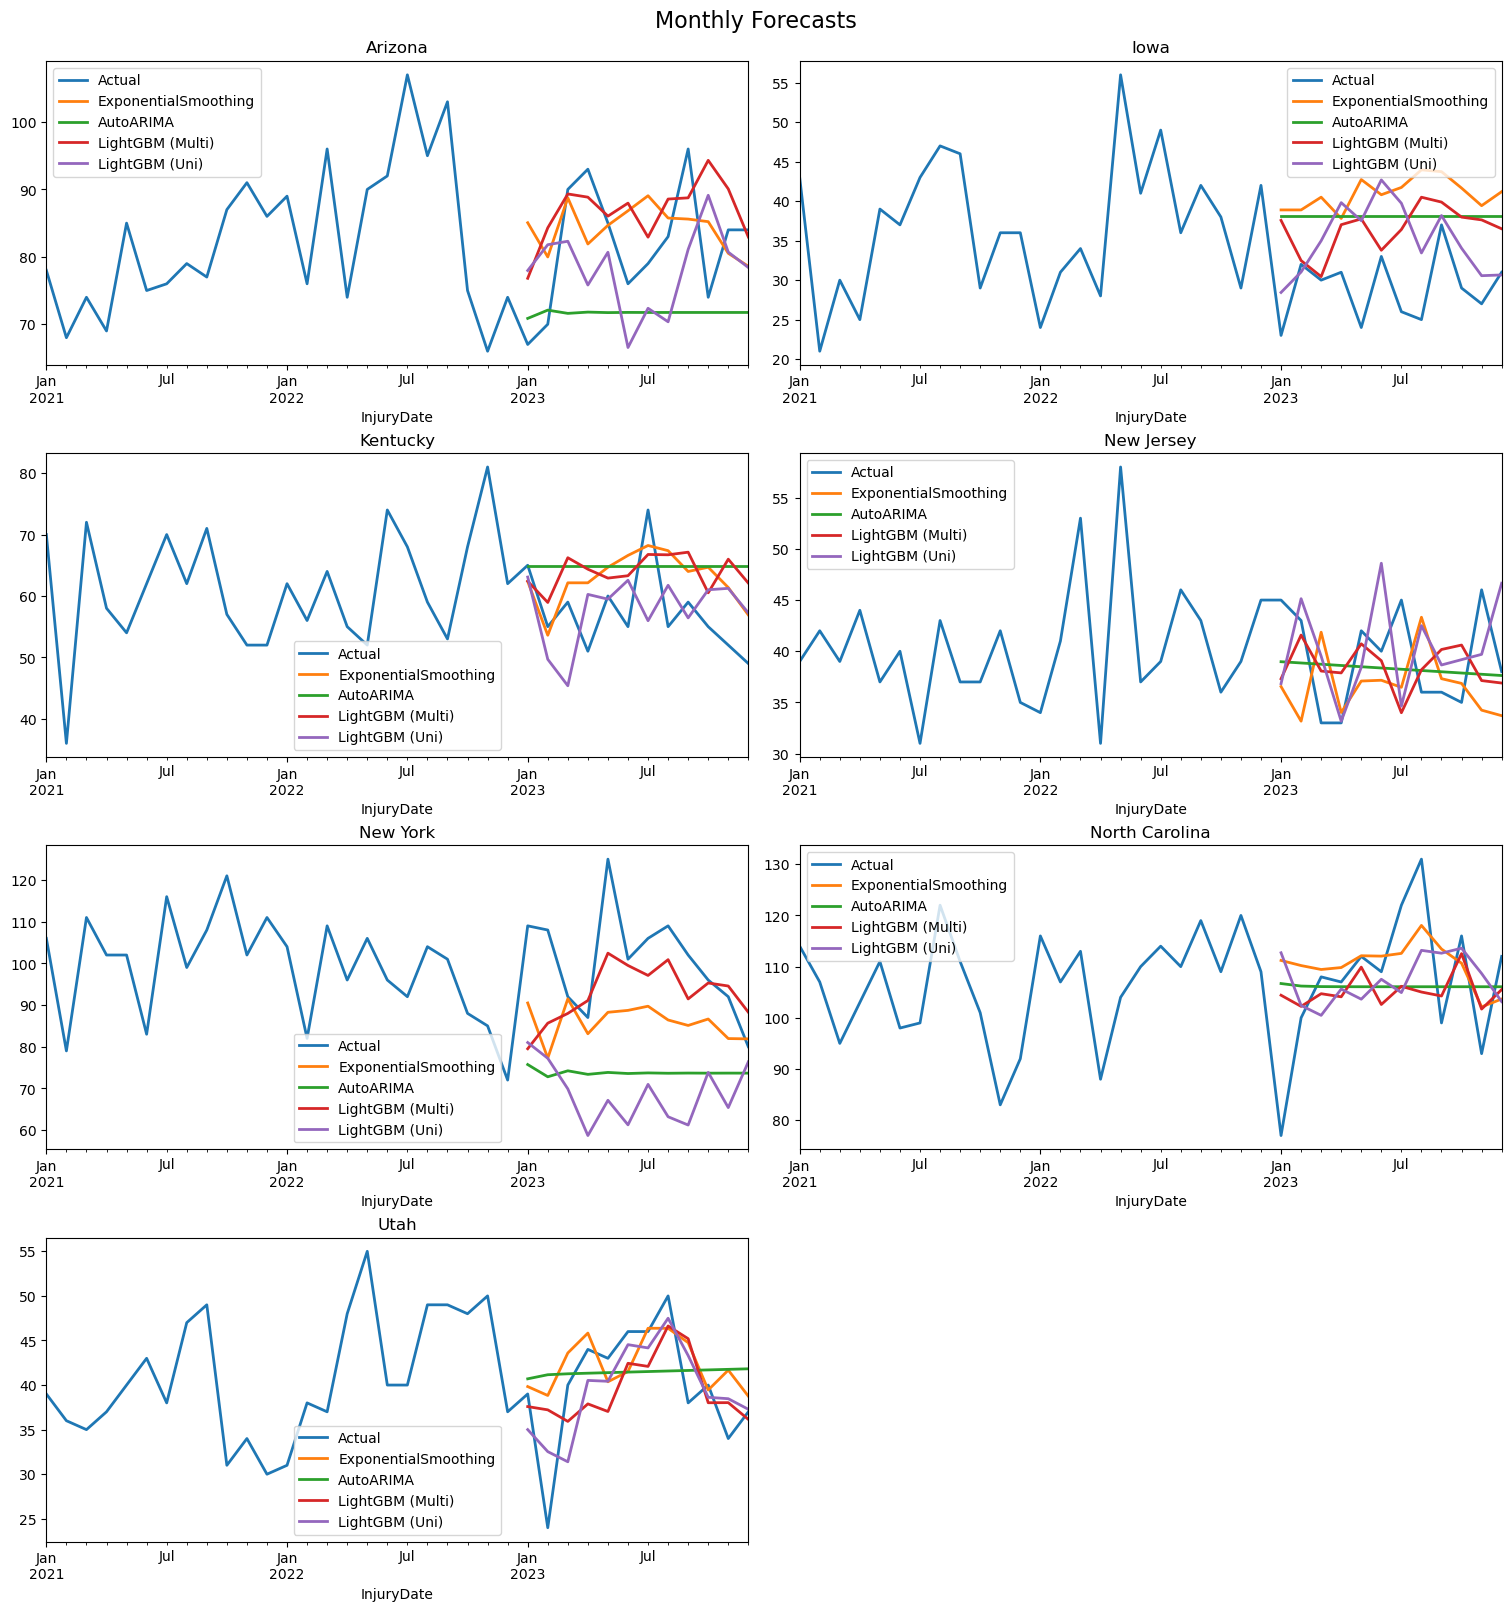

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 695, number of used features: 24
[LightGBM] [Info] Start training from score 11.733813
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 695, number of used features: 24
[LightGBM] [Info] Start training from score 4.683453
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 560
[LightGBM] [Info] Number of data points in the train set: 695, number of used features: 24
[LightGBM] [Info] Start training from score 13.277698
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

...

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 648
[LightGBM] [Info] Number of data points in the train set: 695, number of used features: 24
[LightGBM] [Info] Start training from score 23.507914
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 432
[LightGBM] [Info] Number of data points in the train set: 695, number of used features: 24
[LightGBM] [Info] Start training from score 8.307914
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

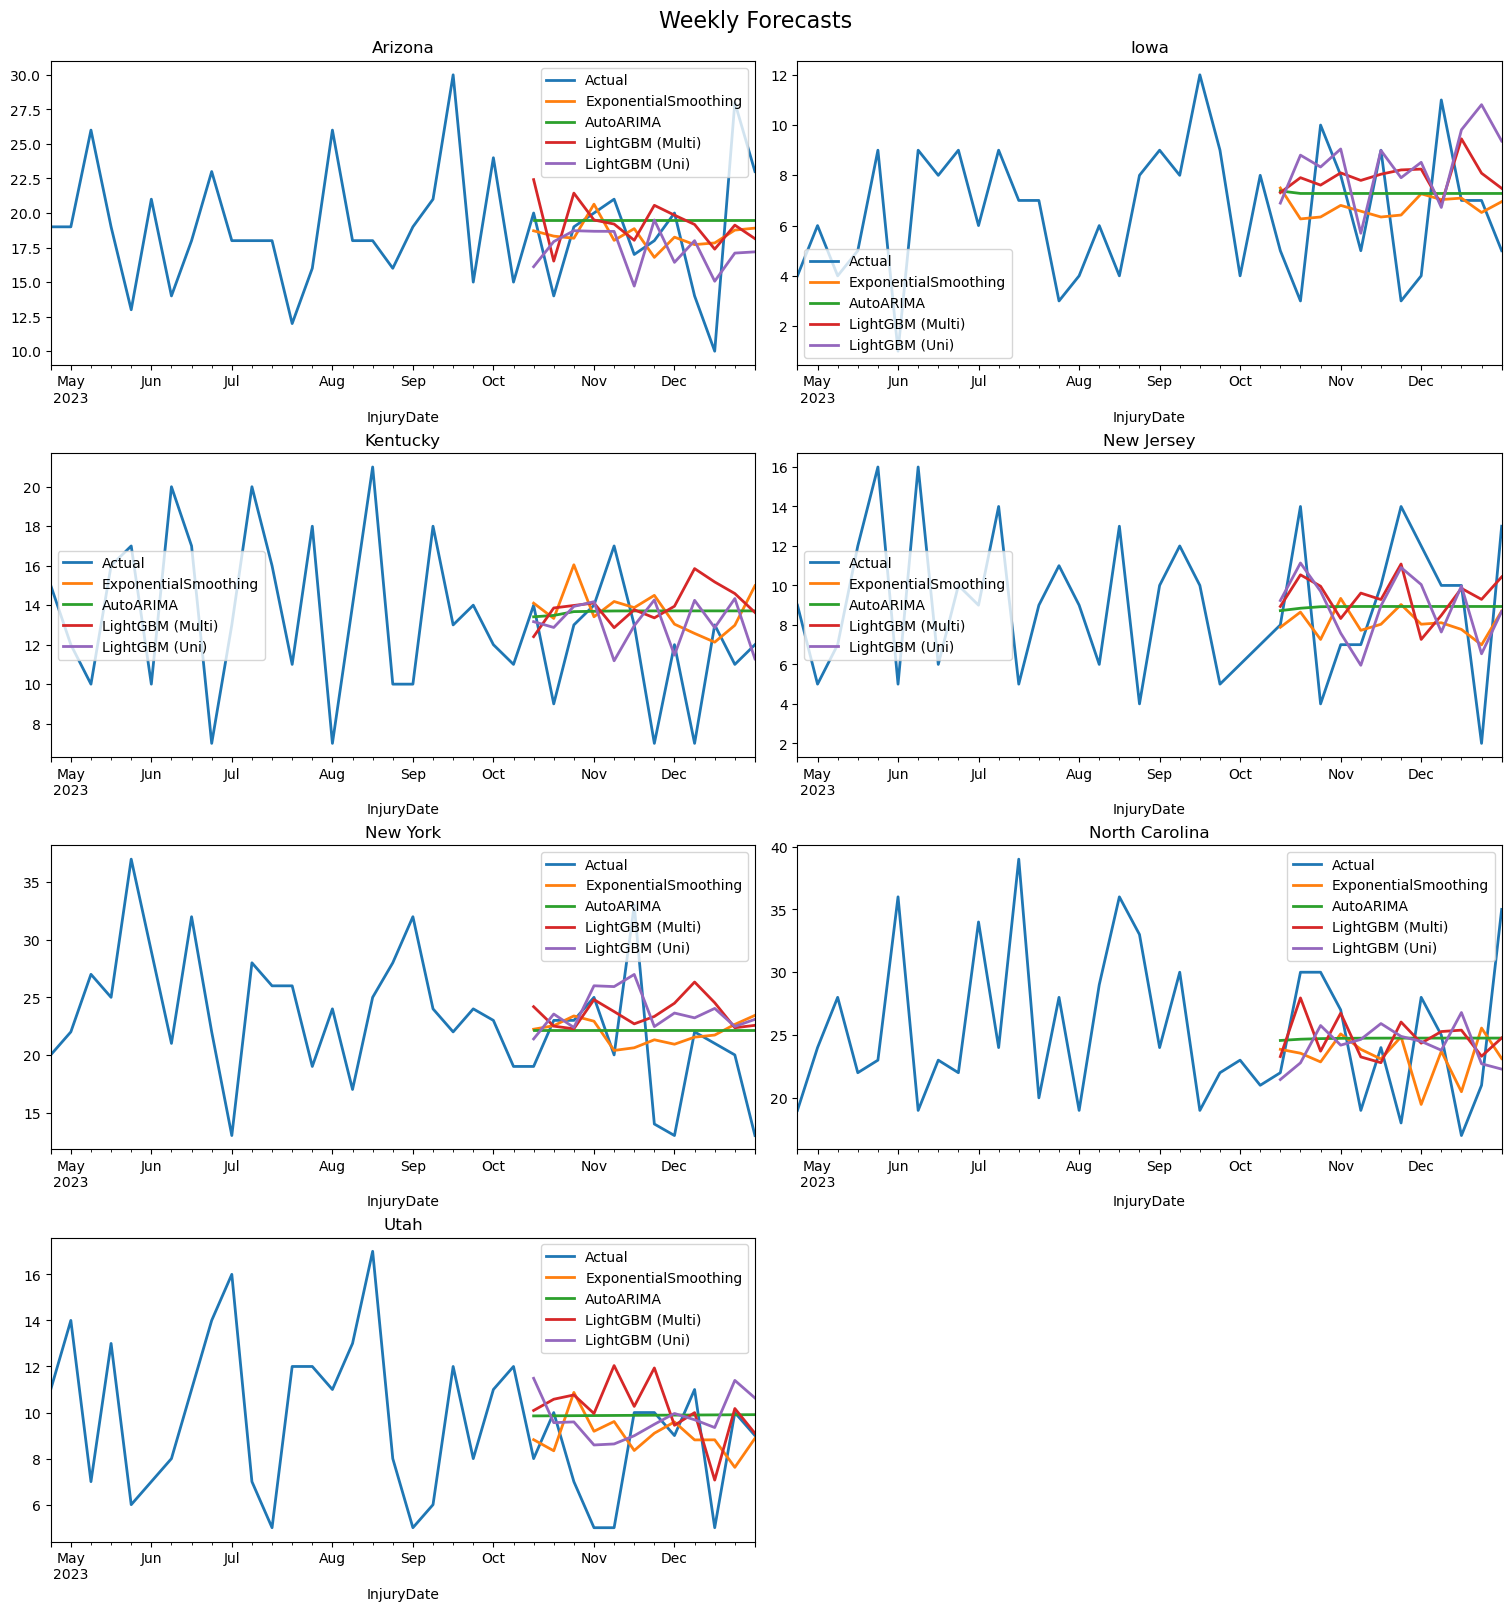

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 5023, number of used features: 60
[LightGBM] [Info] Start training from score 1.652001


/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002833 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 420
[LightGBM] [Info] Number of data points in the train set: 5023, number of used features: 60
[LightGBM] [Info] Start training from score 0.657575


/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 540
[LightGBM] [Info] Number of data points in the train set: 5023, number of used features: 60
[LightGBM] [Info] Start training from score 1.888712


...

/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 720
[LightGBM] [Info] Number of data points in the train set: 5023, number of used features: 60
[LightGBM] [Info] Start training from score 3.354768


/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 5023, number of used features: 60
[LightGBM] [Info] Start training from score 1.183357


/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suicide_forecast/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/suici

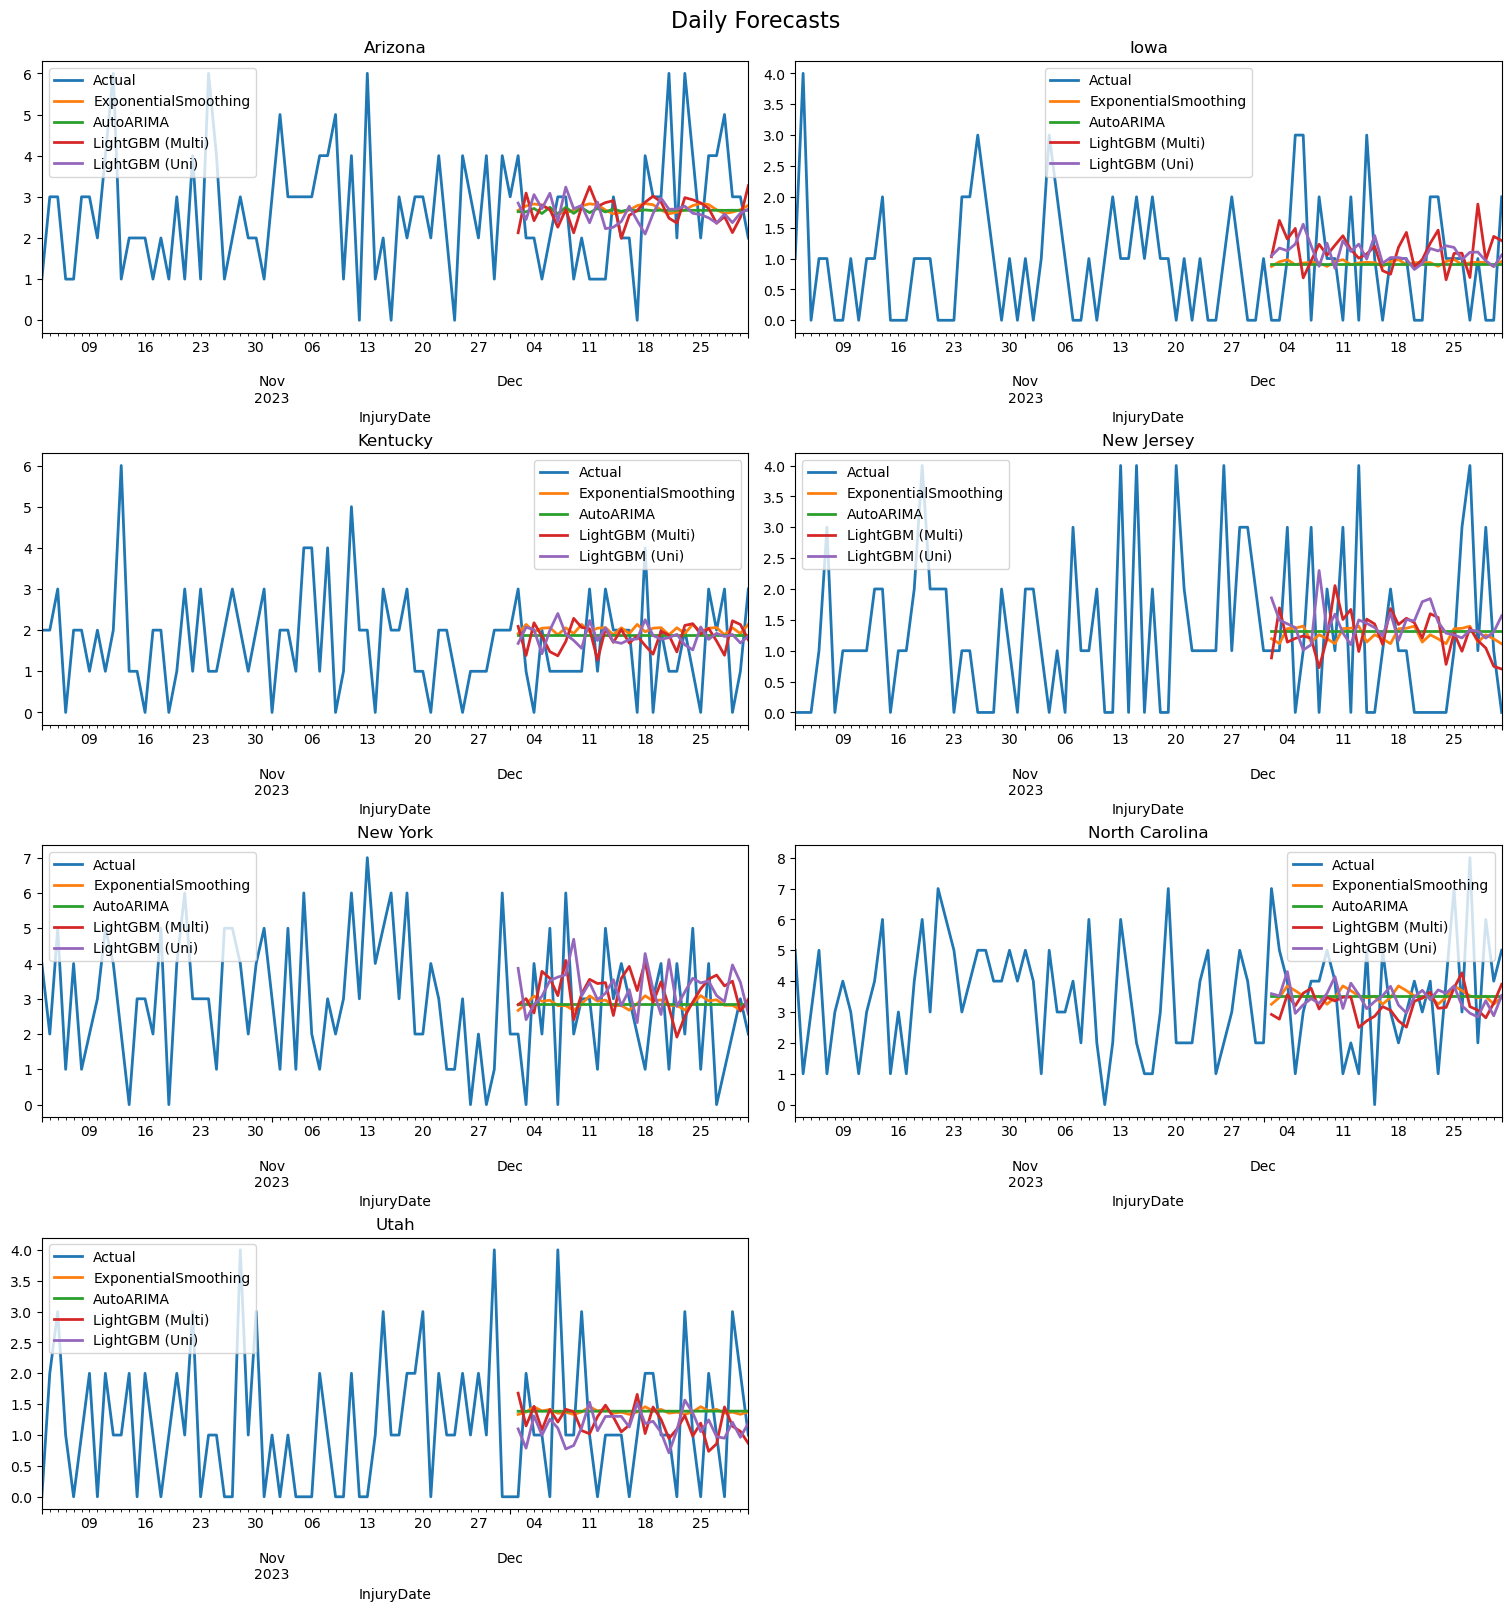

In [12]:
# {Name: (TimeSeries, Validation_Length, LGBM_Lags)} # lags=12 means it uses the past 12 months to predict the next month
timeframes = {
    'Monthly': (ts_monthly, 12, 24), # using `LGBM_Lags` months to predict `Validation_Length` month
    'Weekly': (ts_weekly, 12, 24),
    'Daily': (ts_daily, 30, 60)
}

cols = 2
rows = math.ceil(len(selected_states) / cols)

for name, (ts_data, val_len, lags) in timeframes.items():
    plot_len = val_len * 3 
    
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 4 * rows), constrained_layout=True)
    axes = axes.flatten()
    fig.suptitle(f"{name} Forecasts", fontsize=16)
    
    # --- LightGBM (Multivariate handling) ---
    model_path = f"../artifacts/lgbm_model_{name}_NVDRS.pkl"
    pred_path = f"../artifacts/lgbm_pred_{name}_NVDRS.pkl"
    
    train_multi = ts_data[:-val_len]
    
    # fit and forecast only if the pkl files don't exist
    if os.path.exists(pred_path):
        with open(pred_path, "rb") as f:
            lgbm_pred = pickle.load(f)
    else:
        if os.path.exists(model_path):
            lgbm_model = LightGBMModel.load(model_path)
        else:
            lgbm_model = LightGBMModel(lags=lags)
            lgbm_model.fit(train_multi)
            lgbm_model.save(model_path)
        
        lgbm_pred = lgbm_model.predict(val_len)
        with open(pred_path, "wb") as f:
            pickle.dump(lgbm_pred, f)
            
    # --- Univariate Models & Plotting ---
    for i, state in enumerate(selected_states):
        ts = ts_data[state]
        train = ts[:-val_len]
        
        es_pred = ExponentialSmoothing().fit(train).predict(val_len)
        aa_pred = AutoARIMA().fit(train).predict(val_len)
        lgbm_uni_pred = LightGBMModel(lags=lags).fit(train).predict(val_len)
        
        ts[-plot_len:].plot(ax=axes[i], label='Actual')
        es_pred.plot(ax=axes[i], label='ExponentialSmoothing', lw=2)
        aa_pred.plot(ax=axes[i], label='AutoARIMA', lw=2)
        lgbm_pred[state].plot(ax=axes[i], label='LightGBM (Multi)', lw=2)
        lgbm_uni_pred.plot(ax=axes[i], label='LightGBM (Uni)', lw=2)
        
        axes[i].set_title(state)
        axes[i].legend()
        
    for j in range(len(selected_states), len(axes)):
        axes[j].axis('off')
        
    plt.show()